# Module 0

## Dataset: Child Mind Institute — Problematic Internet Use

Explore and analyse the dataset to understand its structure and key characteristics (describe
them); Conduct data pre-processing (i.e., encoding categorical variables, feature scaling,
missing values imputation); Create new variables if needed.

## Step 00: Setup & Load

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 90)

df = pd.read_csv("../../base_data/cmi_internet.csv")


# Quick descriptive statistics for all numeric columns
df

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,PCIAT-Season,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.00,50.8,26.00,NaN,NaN,114.0,Spring,5.0,7.0,28.0,Fall,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,Fall,2.0,2.668550,16.879200,932.498000,1492.000000,8.255980,41.586200,13.817700,3.061430,9.213770,1.0,24.434900,8.895360,38.917700,19.541300,32.690900,Winter,NaN,NaN,NaN,Fall,5.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.00,46.0,22.00,75.0,70.0,122.0,NaN,NaN,NaN,28.0,Fall,3.0,0.0,NaN,2.0,NaN,2.0,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,Winter,2.0,2.579490,14.037100,936.656000,1498.650000,6.019930,42.029100,12.825400,1.211720,3.970850,1.0,21.035200,14.974000,39.449700,15.410700,27.055200,Winter,2.01,Fall,2.340,Fall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.50,75.6,NaN,65.0,94.0,117.0,Fall,5.0,7.0,33.0,Fall,20.0,1.0,10.20,1.0,14.70,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,NaN,NaN,3.922720,17.966500,1115.380000,1863.980000,15.928000,61.066200,14.092500,3.698630,16.174600,NaN,NaN,NaN,56.996400,NaN,44.987000,NaN,NaN,Summer,2.170,Fall,5.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.00,81.6,26.00,60.0,97.0,117.0,Summer,6.0,9.0,37.0,Summer,18.0,1.0,20.05,NaN,NaN,NaN,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,Summer,3.0,3.841910,18.294300,1131.430000,1923.440000,15.592500,62.775700,14.074000,4.220330,18.824300,2.0,30.404100,16.779000,58.933800,26.479800,45.996600,NaN,NaN,Winter,2.451,Summer,4.0,2.0,4.0,0.0,5.0,1.0,0.0,3.0,2.0,2.0,3.0,0.0,3.0,0.0,0.0,3.0,4.0,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,4,Spring,18,1,Summer,65.0,NaN,17.937682,NaN,77.0,26.00,68.0,NaN,NaN,Spring,NaN,NaN,28.0,NaN,9.0,0.0,NaN,2.0,NaN,NaN,3.0,0.0,NaN,1.0,9.0,NaN,10.0,1.0,NaN,NaN,NaN,NaN,NaN,1863.980000,15.928000,NaN,NaN,3.698630,16.174600,2.0,28.855800,NaN,56.996400,NaN,NaN,Summer,1.04,Spring,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,Spring,7,1,Spring,NaN,Fall,16.130585,46.07,49.0,22.25,58.5,82.5,NaN,NaN,2.5,8.5,NaN,Summer,4.5,1.0,17.40,2.0,18.75,NaN,2.0,1.0,8.0,1.0,6.0,0.0,8.0,1.0,Fall,1.0,2.625946,14.813292,979.009933,1490.8

---
## Step 01. Data visualization

We explore each feature's distribution to spot outliers and wrong data.

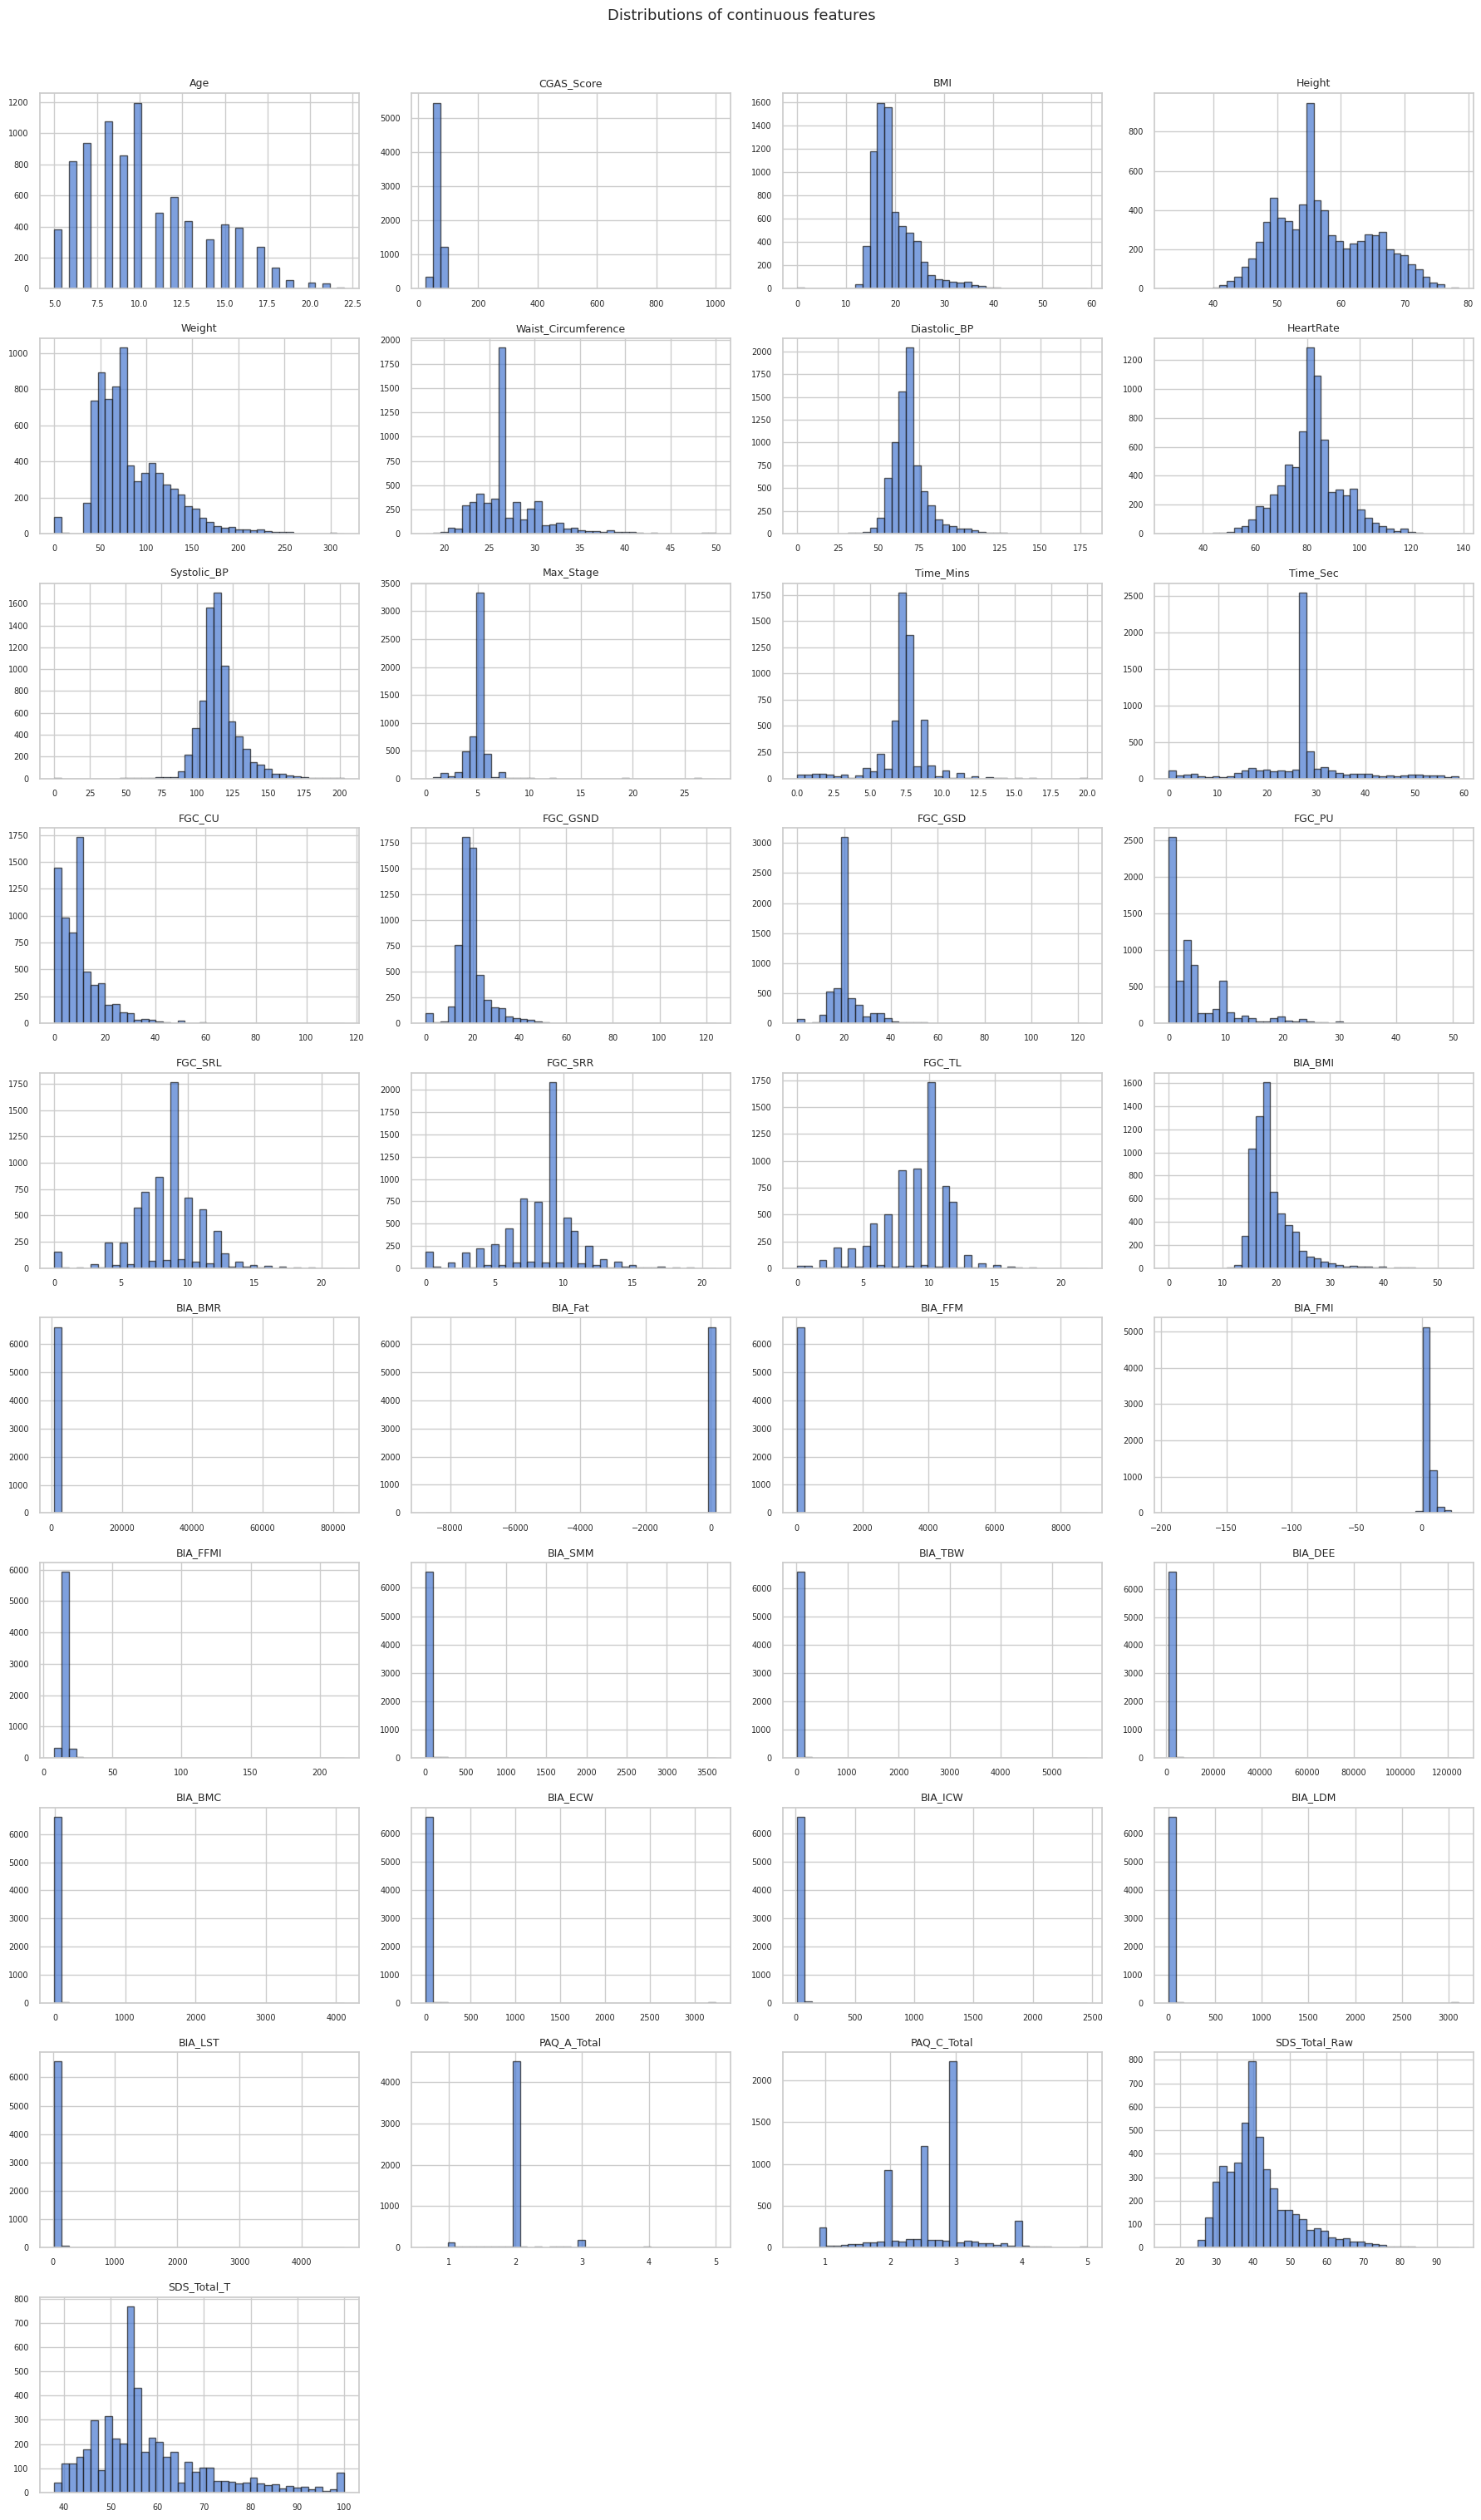

In [5]:
# Histograms of key continuous features (non-PCIAT, non-Season)
cont_cols = [
    "Basic_Demos-Age", "CGAS-CGAS_Score",
    "Physical-BMI", "Physical-Height", "Physical-Weight",
    "Physical-Waist_Circumference", "Physical-Diastolic_BP",
    "Physical-HeartRate", "Physical-Systolic_BP",
    "Fitness_Endurance-Max_Stage", "Fitness_Endurance-Time_Mins",
    "Fitness_Endurance-Time_Sec",
    "FGC-FGC_CU", "FGC-FGC_GSND", "FGC-FGC_GSD",
    "FGC-FGC_PU", "FGC-FGC_SRL", "FGC-FGC_SRR", "FGC-FGC_TL",
    "BIA-BIA_BMI", "BIA-BIA_BMR", "BIA-BIA_Fat", "BIA-BIA_FFM",
    "BIA-BIA_FMI", "BIA-BIA_FFMI", "BIA-BIA_SMM", "BIA-BIA_TBW",
    "BIA-BIA_DEE", "BIA-BIA_BMC", "BIA-BIA_ECW", "BIA-BIA_ICW",
    "BIA-BIA_LDM", "BIA-BIA_LST",
    "PAQ_A-PAQ_A_Total", "PAQ_C-PAQ_C_Total",
    "SDS-SDS_Total_Raw", "SDS-SDS_Total_T",
]

n = len(cont_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    df[col].dropna().hist(bins=40, ax=axes[i], edgecolor="k", alpha=0.7)
    axes[i].set_title(col.split("-")[-1], fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distributions of continuous features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

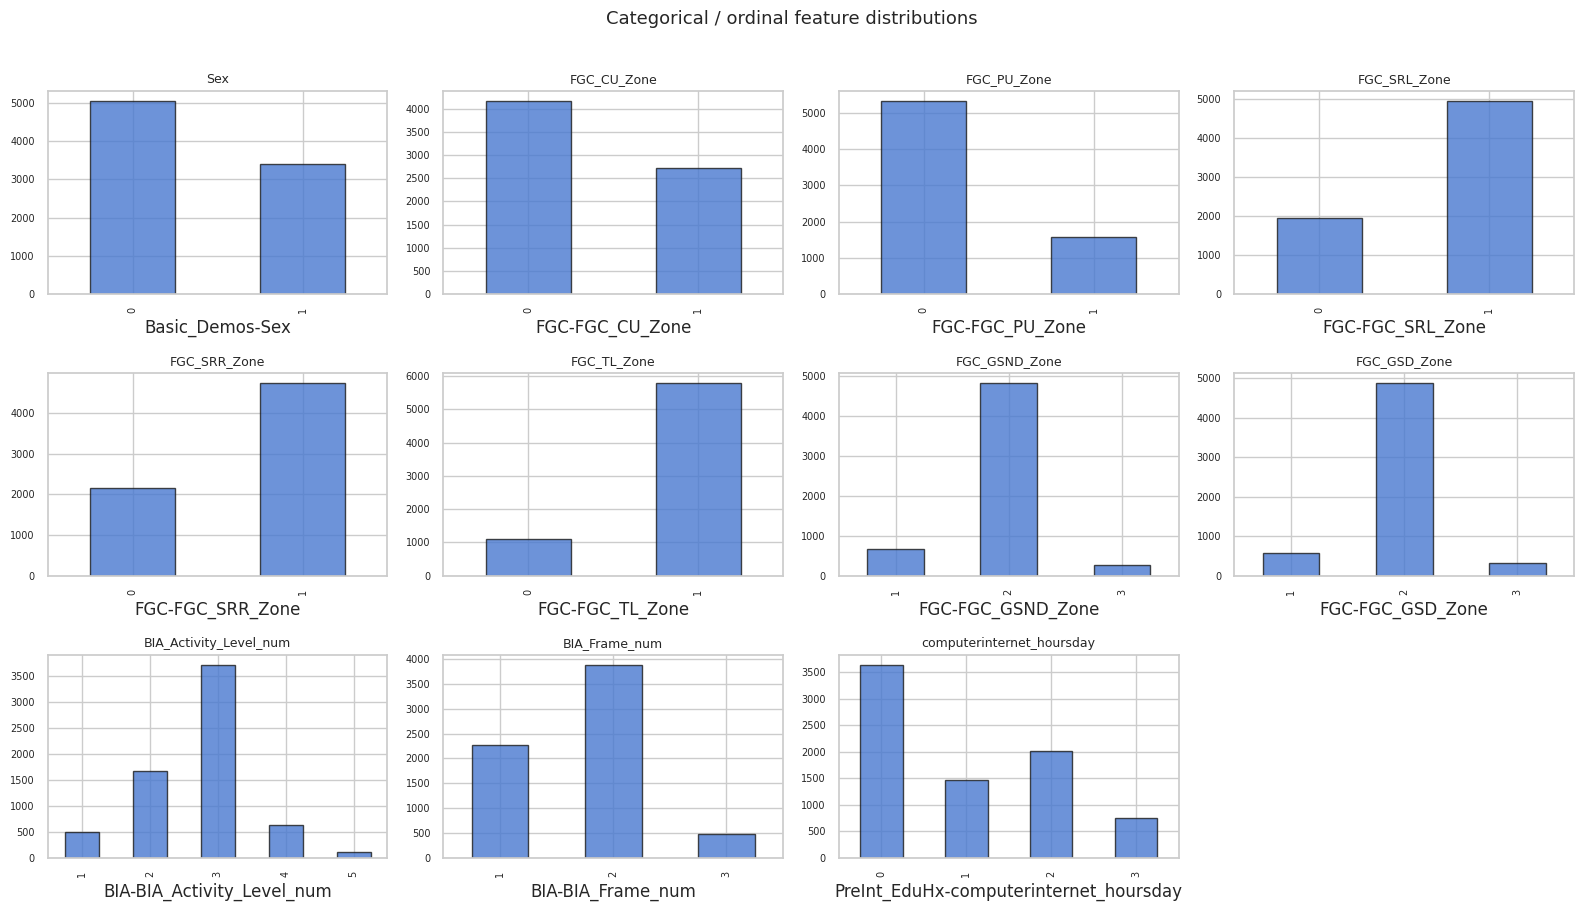

In [6]:
# Bar plots for categorical / ordinal features
cat_cols = [
    "Basic_Demos-Sex",
    "FGC-FGC_CU_Zone", "FGC-FGC_PU_Zone", "FGC-FGC_SRL_Zone",
    "FGC-FGC_SRR_Zone", "FGC-FGC_TL_Zone",
    "FGC-FGC_GSND_Zone", "FGC-FGC_GSD_Zone",
    "BIA-BIA_Activity_Level_num", "BIA-BIA_Frame_num",
    "PreInt_EduHx-computerinternet_hoursday",
]

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].dropna().astype(int).value_counts().sort_index().plot.bar(
        ax=axes[i], edgecolor="k", alpha=0.8)
    axes[i].set_title(col.split("-")[-1], fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Categorical / ordinal feature distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

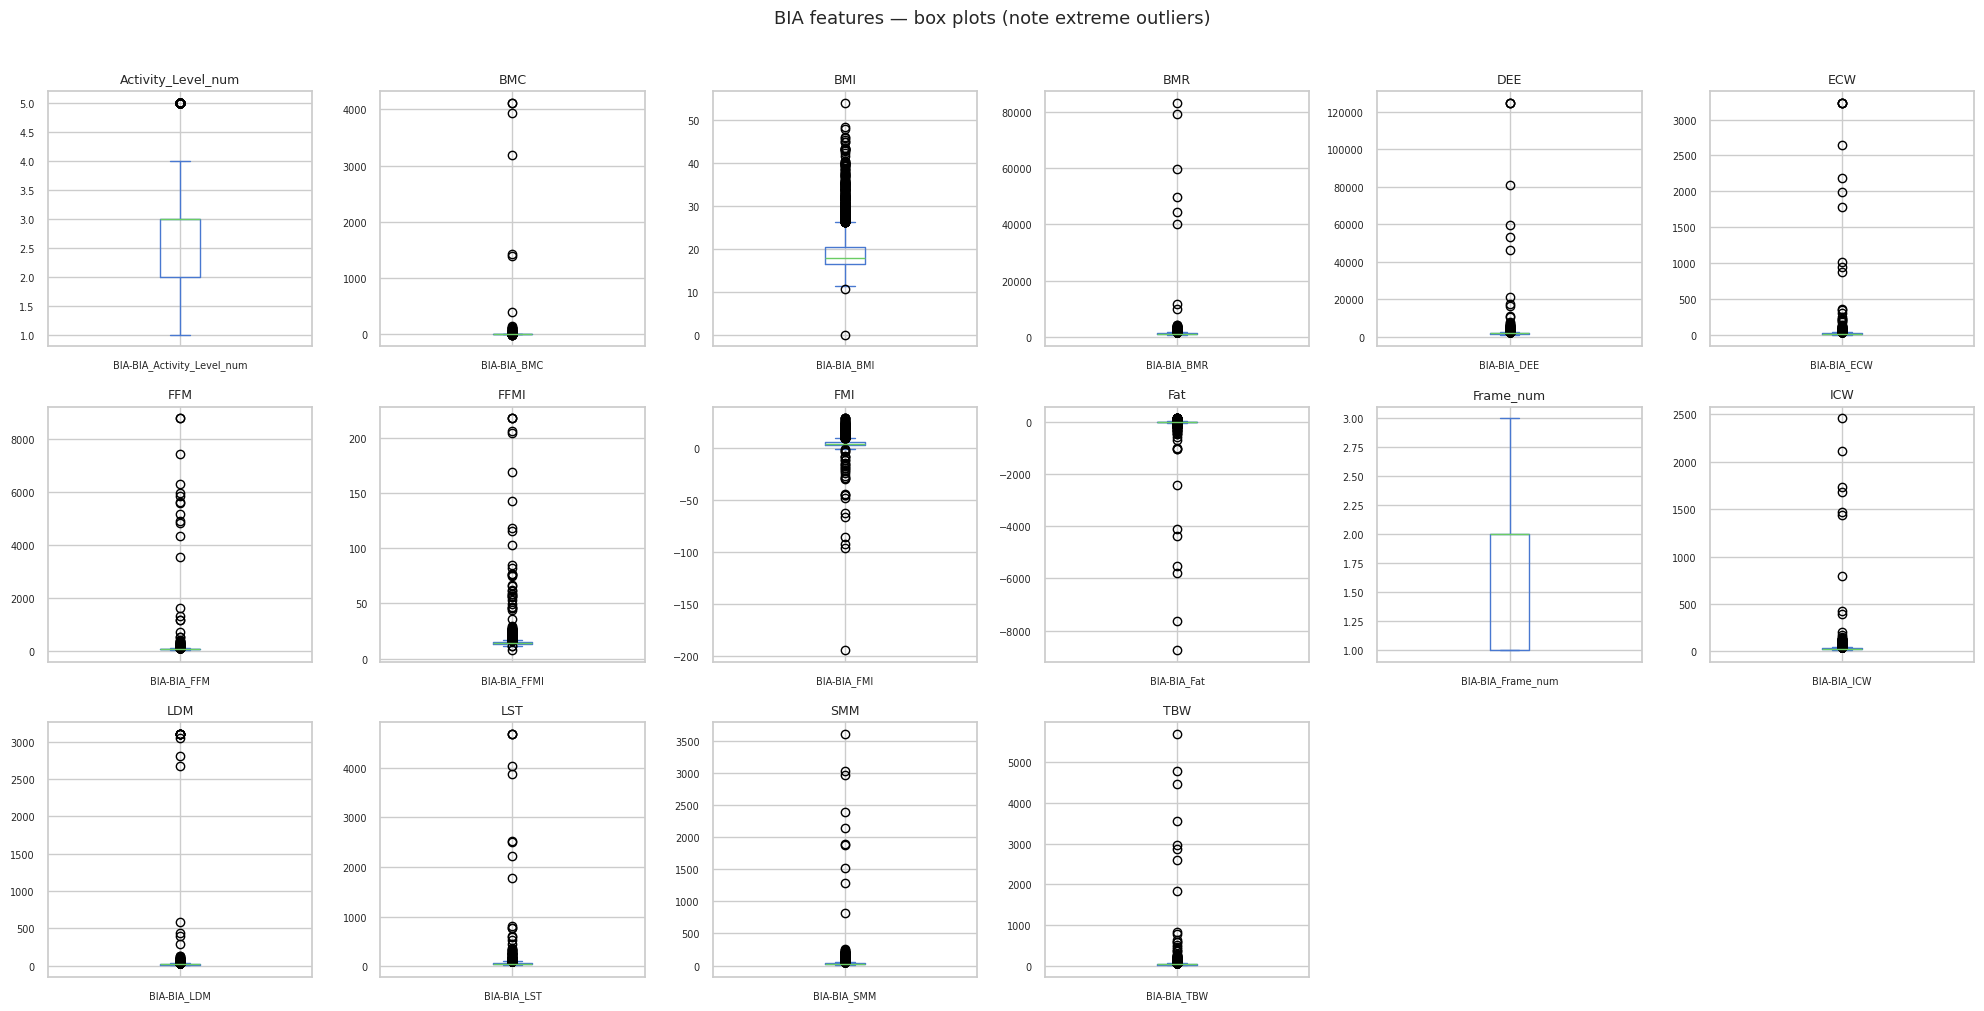

In [7]:
# Box plots to spot outliers
bia_cols = [c for c in df.columns if c.startswith("BIA-") and "Season" not in c]
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(bia_cols):
    df[col].dropna().plot.box(ax=axes[i], vert=True)
    axes[i].set_title(col.replace("BIA-BIA_", ""), fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("BIA features — box plots (note extreme outliers)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Main observations:

- many continuous features contain erroneous datam with also many outliers
- various continuous columns show extreme tails
- the target variable `sii` is heavily imbalanced

## Step xx - Linear correlation

In [8]:
# Correlation heatmap among variables (excluding PCIAT columns)
pciat_cols = [c for c in df.columns if c.startswith("PCIAT-")]
corr_mat = df.drop(columns=pciat_cols).corr(method="spearman", numeric_only=True)
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
fig, ax = plt.subplots(figsize=(36, 36), dpi=400)
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.3, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation heatmap (non-PCIAT features)")
plt.tight_layout()
plt.show()

## Step xx - Target variable analysis

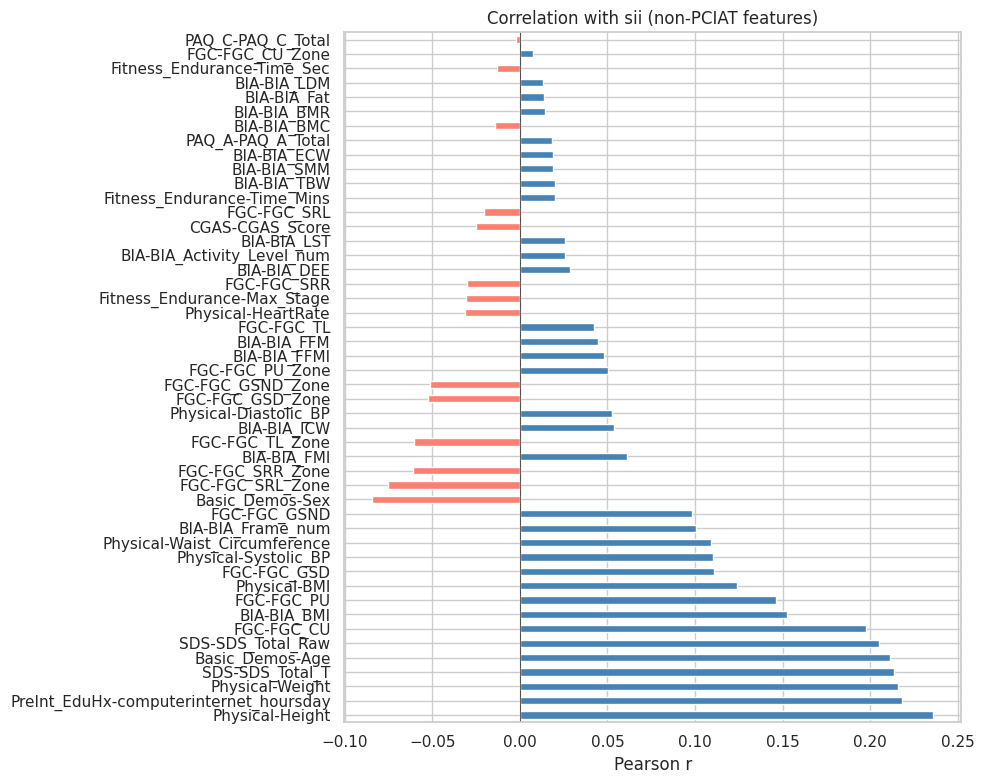

Top 10 absolute correlates:
Physical-Height                           0.235959
PreInt_EduHx-computerinternet_hoursday    0.217851
Physical-Weight                           0.215526
SDS-SDS_Total_T                           0.213574
Basic_Demos-Age                           0.211182
SDS-SDS_Total_Raw                         0.204893
FGC-FGC_CU                                0.197678
BIA-BIA_BMI                               0.152289
FGC-FGC_PU                                0.146300
Physical-BMI                              0.123990


In [9]:
# Correlation with sii — only non-PCIAT, non-Season features
numeric = df.select_dtypes("number").drop(columns=["id"])
pciat_cols = [c for c in numeric.columns if "PCIAT" in c]
corr_sii = (numeric.drop(columns=pciat_cols)
            .corrwith(numeric["sii"])
            .drop("sii")
            .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(10, 8))
corr_sii.plot.barh(ax=ax, color=corr_sii.apply(lambda x: "steelblue" if x >= 0 else "salmon"))
ax.set_title("Correlation with sii (non-PCIAT features)")
ax.set_xlabel("Pearson r")
ax.axvline(0, color="k", lw=0.5)
plt.tight_layout()
plt.show()

print("Top 10 absolute correlates:")
print(corr_sii.head(10).to_string())

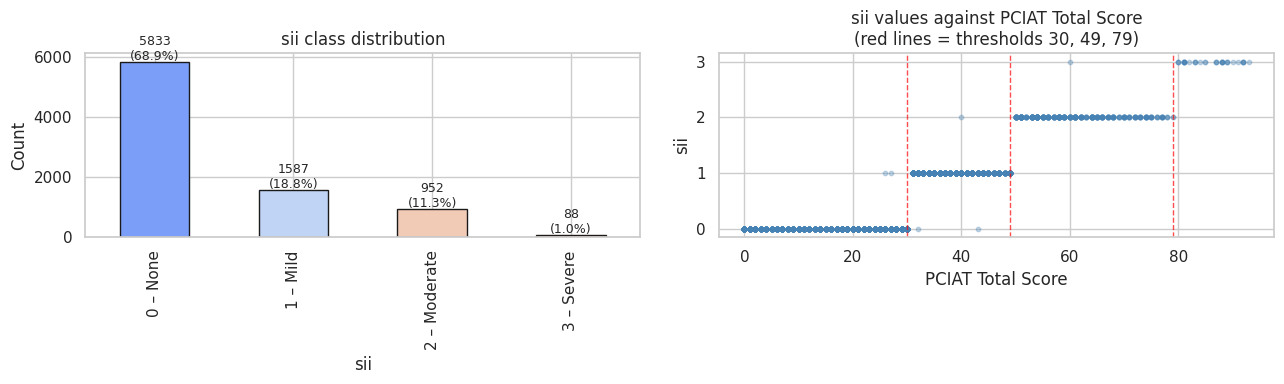

In [10]:
sii_labels = {0: "None", 1: "Mild", 2: "Moderate", 3: "Severe"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class distribution
counts = df["sii"].value_counts().sort_index()
counts.index = counts.index.map(lambda x: f"{int(x)} – {sii_labels[int(x)]}")
counts.plot.bar(ax=axes[0], color=sns.color_palette("coolwarm", 4), edgecolor="k")
axes[0].set_title("sii class distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts):
    axes[0].text(i, v + 50, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)

# sii vs PCIAT_Total — show derivation
mask = df["PCIAT-PCIAT_Total"].notna()
axes[1].scatter(df.loc[mask, "PCIAT-PCIAT_Total"], df.loc[mask, "sii"],
                alpha=0.3, s=10, c="steelblue")
for thr in [30, 49, 79]:
    axes[1].axvline(thr, color="red", ls="--", lw=1, alpha=0.7)
axes[1].set_xlabel("PCIAT Total Score")
axes[1].set_ylabel("sii")
axes[1].set_title("sii values against PCIAT Total Score\n(red lines = thresholds 30, 49, 79)")

plt.tight_layout()
plt.show()

## Step xx - Missing values overview


In [11]:
# Missing values table (only columns with missingness)
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
miss_df = (pd.DataFrame({"missing": miss, "pct": miss_pct})
             .query("missing > 0")
             .sort_values("pct", ascending=False))
miss_df

,missing,pct
PCIAT-PCIAT_18,5746,67.9
PCIAT-PCIAT_17,5746,67.9
PCIAT-PCIAT_16,5746,67.9
PCIAT-PCIAT_04,5746,67.9
PCIAT-PCIAT_03,5746,67.9
...,...,...
Physical-Weight,819,9.7
PreInt_EduHx-computerinternet_hoursday,611,7.2
Physical-Season,602,7.1
FGC-Season,569,6.7


## Step 02 - Data cleaning

We remove clearly wrong data and set `default values` to NaNs to be imputed later

In [12]:
# CGAS scale is 1–100
df_clean = df.loc[(df["CGAS-CGAS_Score"] <= 100) | (df["CGAS-CGAS_Score"].isna())]

# Weight equal to 0 is set as missing
df_clean.loc[df_clean["Physical-Weight"] == 0, "Physical-Weight"] = np.nan

# # Blood pressure of 0 is missing
df_clean.loc[df_clean["Physical-Systolic_BP"] == 0, "Physical-Systolic_BP"] = np.nan
df_clean.loc[df_clean["Physical-Diastolic_BP"] == 0, "Physical-Diastolic_BP"] = np.nan

# # Fat mass index < 0 is an error
df_clean = df_clean.loc[(df["BIA-BIA_FMI"] >= 0) | (df["BIA-BIA_FMI"].isna())]


# # Fat percentage < 0 is an error
df_clean = df_clean.loc[((df["BIA-BIA_Fat"] <= 100) & (df["BIA-BIA_Fat"] >= 0)) | (df["BIA-BIA_Fat"].isna())]

print(f"Removed {len(df)-len(df_clean)} ({100-round((len(df_clean)/len(df))*100)}%) rows")

Removed 201 (2%) rows


## Step xx - Data imputation

In [13]:
cols_to_drop = [
    "id",
    # Season columns
    "Basic_Demos-Enroll_Season",
    "CGAS-Season",
    "Physical-Season",
    "Fitness_Endurance-Season",
    "FGC-Season",
    "BIA-Season",
    "PAQ_A-Season",
    "PAQ_C-Season",
    "PCIAT-Season",
    "SDS-Season",
    "PreInt_EduHx-Season",
    # PCIAT individual items (keep PCIAT_Total — imputed for regression downstream)
    "PCIAT-PCIAT_01", "PCIAT-PCIAT_02", "PCIAT-PCIAT_03", "PCIAT-PCIAT_04",
    "PCIAT-PCIAT_05", "PCIAT-PCIAT_06", "PCIAT-PCIAT_07", "PCIAT-PCIAT_08",
    "PCIAT-PCIAT_09", "PCIAT-PCIAT_10", "PCIAT-PCIAT_11", "PCIAT-PCIAT_12",
    "PCIAT-PCIAT_13", "PCIAT-PCIAT_14", "PCIAT-PCIAT_15", "PCIAT-PCIAT_16",
    "PCIAT-PCIAT_17", "PCIAT-PCIAT_18", "PCIAT-PCIAT_19", "PCIAT-PCIAT_20",
    # Physical BMI
    "Physical-BMI"
]

id_col = df_clean["id"].reset_index(drop=True)

sii = df_clean["sii"].copy()
df_to_impute = df_clean.drop(columns=["sii"] + cols_to_drop).copy()

In [14]:
import miceforest as mf

# Cast categorical columns to pd.Categorical
categorical_cols = [
    "Basic_Demos-Sex","FGC-FGC_CU_Zone", "FGC-FGC_GSND_Zone", "FGC-FGC_GSD_Zone", 
    "FGC-FGC_SRL_Zone", "FGC-FGC_SRR_Zone", "FGC-FGC_TL_Zone",
    "FGC-FGC_PU_Zone", "BIA-BIA_Frame_num", "BIA-BIA_Activity_Level_num",
    "PreInt_EduHx-computerinternet_hoursday",
]

for col in categorical_cols:
    df_to_impute[col] = df_to_impute[col].astype("category")
# Columns that should NOT be imputed (and not used as predictors)
do_not_impute = {
    "Physical-BMI",
    "Physical-Waist_Circumference",
    "Fitness_Endurance-Max_Stage",
    "Fitness_Endurance-Time_Mins",
    "Fitness_Endurance-Time_Sec",
    "BIA-BIA_BMC",
    "BIA-BIA_LST",
    "BIA-BIA_BMR",
    "BIA-BIA_TBW",
    "BIA-BIA_ECW",
    "BIA-BIA_ICW",
    "BIA-BIA_SMM",
    "BIA-BIA_LDM",
    "SDS-SDS_Total_Raw",
    "SDS-SDS_Total_T"
}

# PCIAT_Total is imputed (needed for regression downstream) but isolated:
# it is NOT used as a predictor for any other column, to avoid leaking
# PCIAT-derived information into features used by modules 1, 2 and outlier detection.
PCIAT_TOTAL = "PCIAT-PCIAT_Total"

all_cols = list(df_to_impute.columns)

cols_to_impute = [
    c for c in all_cols
    if c not in do_not_impute and df_to_impute[c].isnull().any()
]

variable_schema = {
    col: [
        c for c in all_cols
        if c != col and (col == PCIAT_TOTAL or c != PCIAT_TOTAL)
    ]
    for col in cols_to_impute
}

print(all_cols)

['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP', 'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total', 'PCIAT-PCIAT_Total', 'SDS-SDS_Total_Raw', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday']


In [15]:
# Create imputation kernel and run MICE
NUM_DATASETS = 3
mm_strategy = {col: "shap" for col in categorical_cols if col in cols_to_impute}

df_to_impute = df_to_impute.reset_index(drop=True)

kernel = mf.ImputationKernel(
    data=df_to_impute,
    variable_schema=variable_schema,
    num_datasets=NUM_DATASETS,
    random_state=42,
    mean_match_candidates=5,
    mean_match_strategy=mm_strategy,
)
kernel.mice(iterations=5, verbose=True)

Initialized logger with name MICE Iterations 1 - 5 and 4 levels
1 Dataset 0
 | PreInt_EduHx-computerinternet_hoursday | Physical-Height | Physical-Weight | Physical-HeartRate | Physical-Diastolic_BP | Physical-Systolic_BP | CGAS-CGAS_Score | FGC-FGC_TL | FGC-FGC_CU | FGC-FGC_SRR | FGC-FGC_PU | FGC-FGC_SRL | FGC-FGC_TL_Zone | FGC-FGC_CU_Zone | FGC-FGC_PU_Zone | FGC-FGC_SRR_Zone | FGC-FGC_SRL_Zone | BIA-BIA_BMI | BIA-BIA_FMI | BIA-BIA_Activity_Level_num | BIA-BIA_DEE | BIA-BIA_Frame_num | BIA-BIA_FFM | BIA-BIA_FFMI | BIA-BIA_Fat | PAQ_C-PAQ_C_Total | FGC-FGC_GSND | FGC-FGC_GSD | FGC-FGC_GSD_Zone | FGC-FGC_GSND_Zone | PAQ_A-PAQ_A_Total | PCIAT-PCIAT_Total
Dataset 1
 | PreInt_EduHx-computerinternet_hoursday | Physical-Height | Physical-Weight | Physical-HeartRate | Physical-Diastolic_BP | Physical-Systolic_BP | CGAS-CGAS_Score | FGC-FGC_TL | FGC-FGC_CU | FGC-FGC_SRR | FGC-FGC_PU | FGC-FGC_SRL | FGC-FGC_TL_Zone | FGC-FGC_CU_Zone | FGC-FGC_PU_Zone | FGC-FGC_SRR_Zone | FGC-FGC_SRL_Zone | BIA-

In [16]:
# Pool across all imputed datasets:
# - Continuous columns: average across datasets
# - Categorical columns: majority vote across datasets
all_datasets = [kernel.complete_data(dataset=i) for i in range(NUM_DATASETS)]

continuous_cols = [c for c in df_to_impute.columns if c not in categorical_cols]

df_imputed = all_datasets[0].copy()

# Average continuous columns across all datasets
for col in continuous_cols:
    df_imputed[col] = np.mean([ds[col].values for ds in all_datasets], axis=0)

# Majority vote for categorical columns across all datasets
for col in categorical_cols:
    stacked = pd.DataFrame({i: ds[col] for i, ds in enumerate(all_datasets)})
    df_imputed[col] = stacked.mode(axis=1)[0]

# Re-attach the target
df_imputed["sii"] = sii.values

# Verify: no missing values remain
print(f"Missing values after imputation: {df_imputed.isnull().sum().sum()}")
print(f"Shape: {df_imputed.shape}")
print()

# Sanity check: categorical columns still have valid discrete values
print("Categorical columns — unique values after imputation:")
for col in categorical_cols:
    vals = sorted(df_imputed[col].dropna().unique())
    print(f"  {col.split('-')[-1]}: {vals}")
df_imputed

Missing values after imputation: 32798
Shape: (8259, 49)

Categorical columns — unique values after imputation:
  Sex: [0, 1]
  FGC_CU_Zone: [0.0, 1.0]
  FGC_GSND_Zone: [1.0, 2.0, 3.0]
  FGC_GSD_Zone: [1.0, 2.0, 3.0]
  FGC_SRL_Zone: [0.0, 1.0]
  FGC_SRR_Zone: [0.0, 1.0]
  FGC_TL_Zone: [0.0, 1.0]
  FGC_PU_Zone: [0.0, 1.0]
  BIA_Frame_num: [1.0, 2.0, 3.0]
  BIA_Activity_Level_num: [1.0, 2.0, 3.0, 4.0, 5.0]
  computerinternet_hoursday: [0.0, 1.0, 2.0, 3.0]


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-PAQ_A_Total,PAQ_C-PAQ_C_Total,PCIAT-PCIAT_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii
0,5.0,0,51.000000,46.000000,50.8,26.00,69.333333,89.833333,114.0,5.0,7.0,28.0,0.0,0.0,15.033333,2.0,16.666667,2.0,0.000000,0.0,7.0,0.0,6.0,0.0,6.000000,1.0,2.0,2.668550,16.879200,932.498000,1492.000000,8.255980,41.586200,13.817700,3.061430,9.213770,1.0,24.434900,8.895360,38.917700,19.541300,32.690900,2.003333,2.513333,55.000000,NaN,NaN,3.0,2.0
1,9.0,0,57.666667,48.000000,46.0,22.00,75.000000,70.000000,122.0,NaN,NaN,28.0,3.0,0.0,15.483333,2.0,17.100000,2.0,5.000000,0.0,11.0,1.0,11.0,1.0,3.000000,0.0,2.0,2.579490,14.037100,936.656000,1498.650000,6.019930,42.029100,12.825400,1.211720,3.970850,1.0,21.035200,14.974000,39.449700,15.410700,27.055200,2.010000,2.340000,0.000000,46.0,64.0,0.0,0.0
2,10.0,1,71.000000,56.500000,75.6,NaN,65.000000,94.000000,117.0,5.0,7.0,33.0,20.0,1.0,10.200000,1.0,14.700000,2.0,7.000000,1.0,10.0,1.0,10.0,1.0,5.000000,0.0,3.0,3.922720,17.966500,1115.380000,1863.980000,15.928000,61.066200,14.092500,3.698630,16.174600,2.0,NaN,NaN,56.996400,NaN,44.987000,2.010000,2.170000,28.000000,38.0,54.0,2.0,0.0
3,9.0,0,71.000000,56.000000,81.6,26.00,60.000000,97.000000,117.0,6.0,9.0,37.0,18.0,1.0,20.050000,2.0,21.200000,2.0,5.000000,0.0,7.0,0.0,7.0,0.0,7.000000,1.0,3.0,3.841910,18.294300,1131.430000,1923.440000,15.592500,62.775700,14.074000,4.220330,18.824300,2.0,30.404100,16.779000,58.933800,26.479800,45.996600,2.010000,2.451000,44.000000,31.0,45.0,0.0,1.0
4,18.0,1,65.000000,54.666667,77.0,26.00,68.000000,73.833333,114.0,NaN,NaN,28.0,9.0,0.0,14.033333,2.0,21.833333,2.0,3.000000,0.0,9.0,1.0,9.0,1.0,10.000000,1.0,3.0,NaN,17.966500,NaN,1863.980000,15.928000,61.066200,14.092500,3.698630,16.174600,2.0,28.855800,NaN,56.996400,NaN,NaN,1.040000,2.090000,28.666667,NaN,NaN,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8254,16.0,1,62.666667,70.360000,143.9,33.75,64.000000,64.166667,120.5,5.0,7.5,NaN,16.5,0.0,31.300000,3.0,33.250000,3.0,15.333333,1.0,9.0,1.0,11.0,1.0,10.666667,1.0,4.0,7.492883,23.853830,1502.490159,2827.366295,43.422553,115.712153,17.598238,5.254770,37.617123,2.0,45.704166,29.054049,128.756213,73.079335,91.990256,2.336667,3.333333,52.000000,37.5,60.0,2.0,0.0
8255,7.0,1,66.000000,46.070000,49.0,22.25,58.500000,82.500000,103.5,2.5,8.5,NaN,4.5,1.0,17.400000,2.0,18.750000,2.0,2.000000,1.0,8.0,1.0,6.0,0.0,8.000000,1.0,1.0,2.625946,14.813292,979.009933,1490.847845,7.802170,42.546078,13.623619,1.094562,3.173977,1.0,NaN,12.375831,37.154343,NaN,31.583004,2.000000,3.000000,12.000000,38.5,55.0,0.0,0.0
8256,10.0,1,69.500000,56.130000,47.8,28.50,66.000000,80.500000,107.5,5.0,7.5,1.5,7.5,0.0,13.400000,2.0,13.750000,2.0,1.000000,0.0,6.0,0.0,4.0,0.0,8.000000,1.0,3.0,4.987853,15.627678,1029.411546,1678.330810,13.855099,49.863069,13.864269,2.644989,7.651215,1.0,22.690881,16.569017,NaN,22.983200,36.475662,2.000000,3.000000,26.666667,NaN,NaN,0.0,1.0
8257,15.0,1,55.500000,63.790000,99.5,31.10,73.666667,87.500000,108.0,NaN,7.5,28.0,10.0,0.0,21.633333,2.0,26.000000,2.0,0.000000,0.0,11.0,1.0,10.0,1.0,9.000000,1.0,2.0,NaN,19.665279,1379.703447,1674.735823,30.298032,80.716700,16.197522,5.881968,26.7

## Step xx - Drop non-imputed columns

Drop any columns that still contain missing values after imputation (e.g. columns excluded from MICE or rows where the target `sii` is missing).

In [17]:
# Drop columns that still have missing values after imputation
cols_with_na = [c for c in df_imputed.columns if df_imputed[c].isnull().any()]
print(f"Columns with remaining NaN ({len(cols_with_na)}): {cols_with_na}")

df_final = df_imputed.drop(columns=cols_with_na)

print(f"Shape before: {df_imputed.shape}")
print(f"Shape after : {df_final.shape}")
print(f"Missing values: {df_final.isnull().sum().sum()}")
df_final

Columns with remaining NaN (14): ['Physical-Waist_Circumference', 'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec', 'BIA-BIA_BMC', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'SDS-SDS_Total_Raw', 'SDS-SDS_Total_T']
Shape before: (8259, 49)
Shape after : (8259, 35)
Missing values: 0


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,PAQ_A-PAQ_A_Total,PAQ_C-PAQ_C_Total,PCIAT-PCIAT_Total,PreInt_EduHx-computerinternet_hoursday,sii
0,5.0,0,51.000000,46.000000,50.8,69.333333,89.833333,114.0,0.0,0.0,15.033333,2.0,16.666667,2.0,0.000000,0.0,7.0,0.0,6.0,0.0,6.000000,1.0,2.0,16.879200,1492.000000,41.586200,13.817700,3.061430,9.213770,1.0,2.003333,2.513333,55.000000,3.0,2.0
1,9.0,0,57.666667,48.000000,46.0,75.000000,70.000000,122.0,3.0,0.0,15.483333,2.0,17.100000,2.0,5.000000,0.0,11.0,1.0,11.0,1.0,3.000000,0.0,2.0,14.037100,1498.650000,42.029100,12.825400,1.211720,3.970850,1.0,2.010000,2.340000,0.000000,0.0,0.0
2,10.0,1,71.000000,56.500000,75.6,65.000000,94.000000,117.0,20.0,1.0,10.200000,1.0,14.700000,2.0,7.000000,1.0,10.0,1.0,10.0,1.0,5.000000,0.0,3.0,17.966500,1863.980000,61.066200,14.092500,3.698630,16.174600,2.0,2.010000,2.170000,28.000000,2.0,0.0
3,9.0,0,71.000000,56.000000,81.6,60.000000,97.000000,117.0,18.0,1.0,20.050000,2.0,21.200000,2.0,5.000000,0.0,7.0,0.0,7.0,0.0,7.000000,1.0,3.0,18.294300,1923.440000,62.775700,14.074000,4.220330,18.824300,2.0,2.010000,2.451000,44.000000,0.0,1.0
4,18.0,1,65.000000,54.666667,77.0,68.000000,73.833333,114.0,9.0,0.0,14.033333,2.0,21.833333,2.0,3.000000,0.0,9.0,1.0,9.0,1.0,10.000000,1.0,3.0,17.966500,1863.980000,61.066200,14.092500,3.698630,16.174600,2.0,1.040000,2.090000,28.666667,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8254,16.0,1,62.666667,70.360000,143.9,64.000000,64.166667,120.5,16.5,0.0,31.300000,3.0,33.250000,3.0,15.333333,1.0,9.0,1.0,11.0,1.0,10.666667,1.0,4.0,23.853830,2827.366295,115.712153,17.598238,5.254770,37.617123,2.0,2.336667,3.333333,52.000000,2.0,0.0
8255,7.0,1,66.000000,46.070000,49.0,58.500000,82.500000,103.5,4.5,1.0,17.400000,2.0,18.750000,2.0,2.000000,1.0,8.0,1.0,6.0,0.0,8.000000,1.0,1.0,14.813292,1490.847845,42.546078,13.623619,1.094562,3.173977,1.0,2.000000,3.000000,12.000000,0.0,0.0
8256,10.0,1,69.500000,56.130000,47.8,66.000000,80.500000,107.5,7.5,0.0,13.400000,2.0,13.750000,2.0,1.000000,0.0,6.0,0.0,4.0,0.0,8.000000,1.0,3.0,15.627678,1678.330810,49.863069,13.864269,2.644989,7.651215,1.0,2.000000,3.000000,26.666667,0.0,1.0
8257,15.0,1,55.500000,63.790000,99.5,73.666667,87.500000,108.0,10.0,0.0,21.633333,2.0,26.000000,2.0,0.000000,0.0,11.0,1.0,10.0,1.0,9.000000,1.0,2.0,19.665279,1674.735823,80.716700,16.197522,5.881968,26.718654,2.0,2.000000,2.000000,42.666667,1.0,2.0


## Step xx - Restore original precision & dtypes

Imputation + pooling adds precision the raw data never had (fractional integer
scores, float categorical codes, over-precise measurements). We snap every
column back to its original granularity so the processed dataset matches the
source data types.

In [18]:
# MICE + pooling (averaging the continuous columns across the 3 datasets)
# introduces precision/dtype that the raw data never had:
#   - integer scores become fractional      (PCIAT_Total -> 0.333)
#   - categorical codes become floats        (BIA_Frame_num -> 1.0)
#   - measured columns gain spurious decimals (HeartRate -> 89.833333)
# We snap every column back to the granularity it had in the RAW data so the
# processed file matches the original data types. Precision is taken from the
# observed raw values (NOT the data-dictionary nominal type): the dictionary
# calls CGAS/BP/HeartRate "int", but the raw data genuinely carries .5 values
# (averaged across visits), so forcing them to int would corrupt real data.

# Categorical / ordinal codes -> integer (these are stored as discrete labels)
integer_coded = set(categorical_cols) | {"sii"}

def raw_decimals(col):
    """Max number of decimal places seen for `col` in the raw, unimputed data."""
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    d = 0
    for v in s.astype(str):
        if "." in v:
            d = max(d, len(v.split(".")[1].rstrip("0")))
    return d

for col in df_final.columns:
    if col in integer_coded:
        df_final[col] = df_final[col].round().astype(int)
    elif col in df.columns:                 # original measured column
        dec = raw_decimals(col)
        if dec == 0:                        # integer-valued in the raw data
            df_final[col] = df_final[col].round().astype(int)
        else:
            df_final[col] = df_final[col].round(dec)

print("Restored dtypes:")
print(df_final.dtypes.to_string())

Restored dtypes:
Basic_Demos-Age                             int64
Basic_Demos-Sex                             int64
CGAS-CGAS_Score                           float64
Physical-Height                           float64
Physical-Weight                           float64
Physical-Diastolic_BP                     float64
Physical-HeartRate                        float64
Physical-Systolic_BP                      float64
FGC-FGC_CU                                float64
FGC-FGC_CU_Zone                             int64
FGC-FGC_GSND                              float64
FGC-FGC_GSND_Zone                           int64
FGC-FGC_GSD                               float64
FGC-FGC_GSD_Zone                            int64
FGC-FGC_PU                                  int64
FGC-FGC_PU_Zone                             int64
FGC-FGC_SRL                               float64
FGC-FGC_SRL_Zone                            int64
FGC-FGC_SRR                               float64
FGC-FGC_SRR_Zone                 

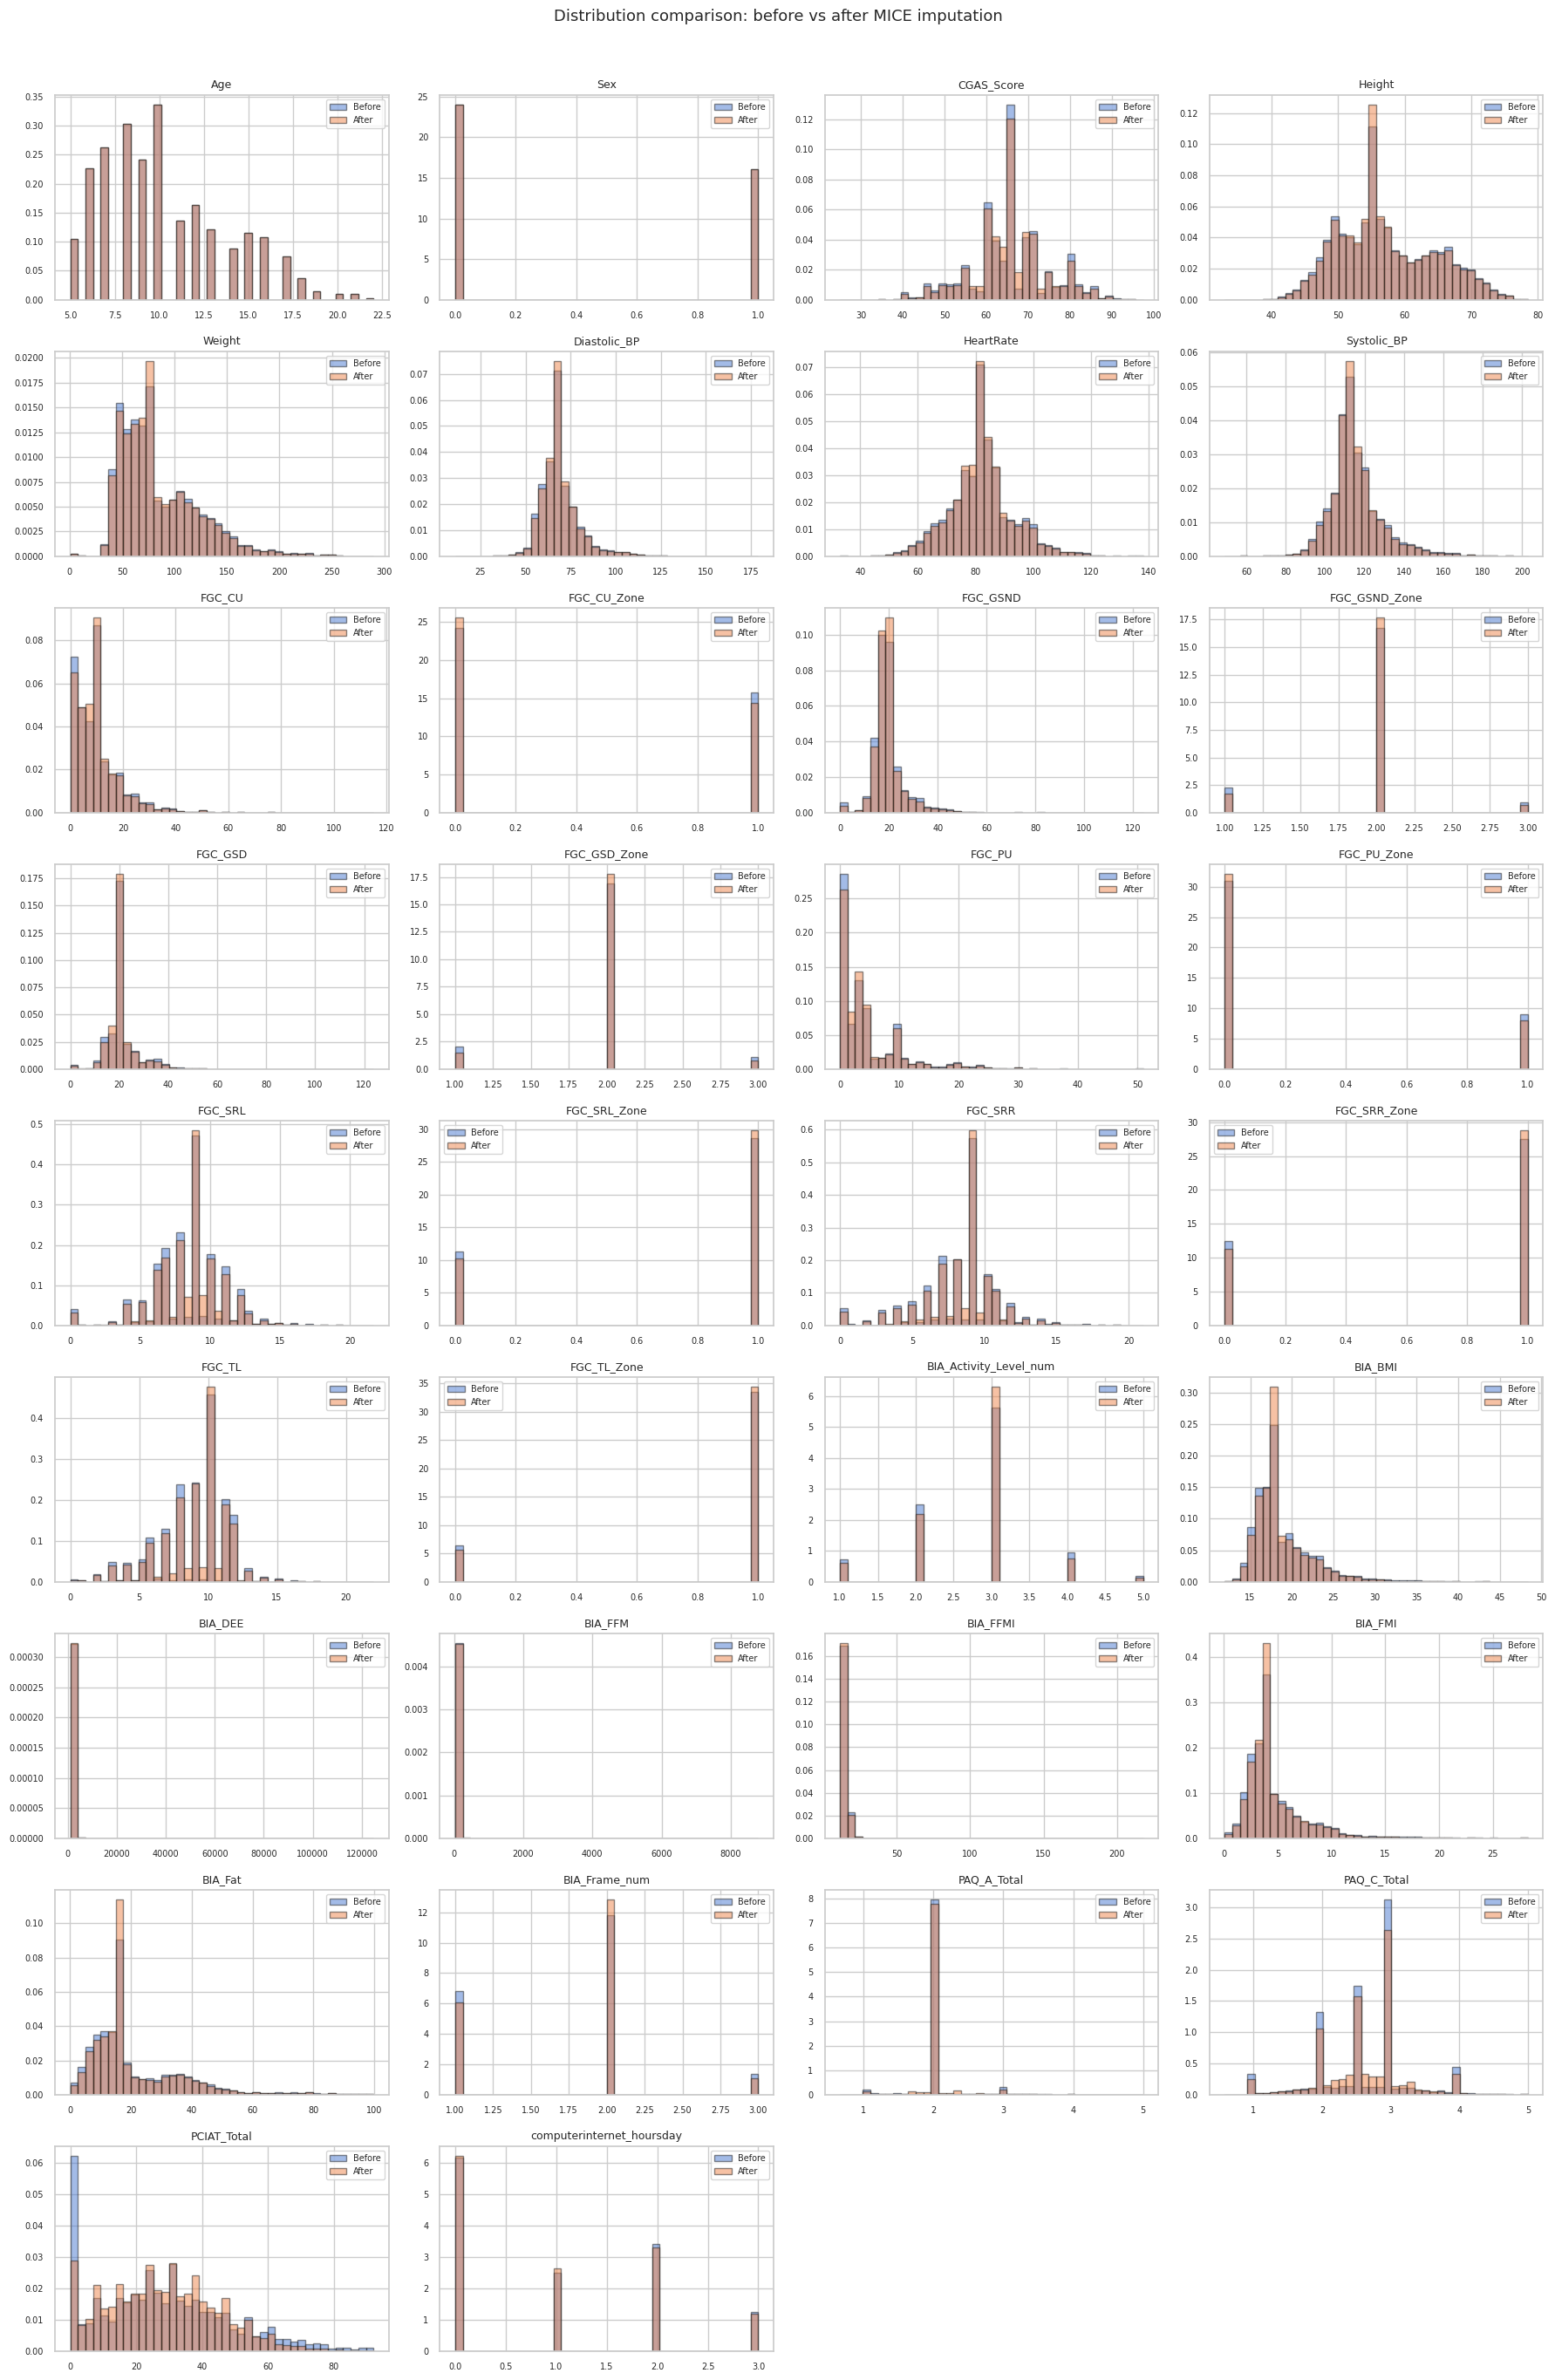

In [19]:
# Compare distributions before vs after imputation for ALL columns
check_cols = [c for c in df_final.columns if c != "sii"]

ncols = 4
nrows = (len(check_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    axes[i].hist(df_to_impute[col].dropna(), bins=40, alpha=0.5, label="Before", density=True, edgecolor="k")
    axes[i].hist(df_final[col].dropna(), bins=40, alpha=0.5, label="After", density=True, edgecolor="k")
    axes[i].set_title(col.split("-")[-1], fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribution comparison: before vs after MICE imputation", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Step xx. Unit Conversion (Imperial → Metric)

In [20]:
# Convert imperial → metric
df_final["Physical-Height"] = df_final["Physical-Height"] * 2.54          # in → cm
df_final["Physical-Weight"] = df_final["Physical-Weight"] * 0.453592      # lbs → kg

print("Converted to metric:")
print(f"  Height: {df_final['Physical-Height'].describe()[['mean','min','max']].to_string()}")
print(f"  Weight: {df_final['Physical-Weight'].describe()[['mean','min','max']].to_string()}")

Converted to metric:
  Height: mean    145.003476
min      83.820000
max     199.390000
  Weight: mean     38.331366
min       0.317514
max     131.360243


## Step xx. Feature Engineering

In [21]:
# We binarize the categorical ones
df_final["FGC-FGC_GSD_Zone"] = df_final["FGC-FGC_GSD_Zone"].map({1: 0, 2: 1, 3: 1})
df_final["FGC-FGC_GSND_Zone"] = df_final["FGC-FGC_GSND_Zone"].map({1: 0, 2: 1, 3: 1})

In [22]:
df_final["Physical-Mean_arterial_pressure"] = (df_final["Physical-Systolic_BP"]+2*df_final["Physical-Diastolic_BP"])/3
df_final.drop(["Physical-Systolic_BP","Physical-Diastolic_BP"], axis=1, inplace=True)


df_final["BIA-FM"] = df_final["Physical-Weight"]*(df_final["BIA-BIA_Fat"]/100)
df_final.drop(["BIA-BIA_Fat"], axis=1, inplace=True)


zone_cols = ["FGC-FGC_CU_Zone", "FGC-FGC_GSND_Zone", "FGC-FGC_GSD_Zone",
             "FGC-FGC_PU_Zone", "FGC-FGC_SRL_Zone", "FGC-FGC_SRR_Zone", "FGC-FGC_TL_Zone"]
df_final['FGC-Fitness_score'] = df_final[zone_cols].astype(int).sum(axis=1)
df_final.drop(["FGC-FGC_CU_Zone","FGC-FGC_GSND_Zone","FGC-FGC_GSD_Zone","FGC-FGC_PU_Zone","FGC-FGC_SRL_Zone","FGC-FGC_SRR_Zone","FGC-FGC_TL_Zone", "FGC-FGC_CU", "FGC-FGC_GSND", "FGC-FGC_GSD", "FGC-FGC_PU", "FGC-FGC_SRL", "FGC-FGC_SRR", "FGC-FGC_TL"], axis=1, inplace=True)


paq_a = df_final["PAQ_A-PAQ_A_Total"]
paq_c = df_final["PAQ_C-PAQ_C_Total"]
df_final["PAQ_Combined"] = np.where(
    paq_a.notna() & paq_c.notna(), (paq_a + paq_c) / 2,
    np.where(paq_a.notna(), paq_a, paq_c)
)
df_final.drop(["PAQ_A-PAQ_A_Total", "PAQ_C-PAQ_C_Total"], axis=1, inplace=True)



In [23]:
df_final.insert(0, 'id', id_col)
df_final.to_csv('../../processed_data/cmi_preprocessed.csv', index=False)